<a href="https://colab.research.google.com/github/DuongBMTTNC/Cloud_DA/blob/main/OULAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("anlgrbz/student-demographics-online-education-dataoulad")

Using Colab cache for faster access to the 'student-demographics-online-education-dataoulad' dataset.


In [ ]:
import pandas as pd
import os
os.listdir(path)

['studentRegistration.csv',
 'studentAssessment.csv',
 'studentInfo.csv',
 'studentVle.csv',
 'vle.csv',
 'assessments.csv',
 'courses.csv']

In [ ]:
student_info = pd.read_csv(path + '/studentInfo.csv')
student_vle = pd.read_csv(path + '/studentVle.csv')
student_assessment = pd.read_csv(path + '/studentAssessment.csv')
assessments = pd.read_csv(path + '/assessments.csv')

In [ ]:
print("Student Assessment (trước xử lý):")
print(student_assessment.head())


Student Assessment (trước xử lý):
   id_assessment  id_student  date_submitted  is_banked  score
0           1752       11391              18          0   78.0
1           1752       28400              22          0   70.0
2           1752       31604              17          0   72.0
3           1752       32885              26          0   69.0
4           1752       38053              19          0   79.0


In [ ]:
print("\nSố giá trị thiếu (score):")
print(student_assessment['score'].isnull().sum())


Số giá trị thiếu (score):
173


In [ ]:
student_assessment = student_assessment.dropna(subset=['score'])

In [ ]:
df = student_info.merge(student_assessment, on='id_student')
df = df.merge(assessments, on='id_assessment')

In [ ]:
vle_group = student_vle.groupby('id_student').agg({
    'sum_click': 'sum',
    'date': 'nunique'
}).reset_index()
vle_group.columns = ['id_student', 'total_clicks', 'active_days']

df = df.merge(vle_group, on='id_student', how='left')

In [ ]:
avg_score = df.groupby('id_student')['score'].mean().reset_index()
avg_score.columns = ['id_student', 'avg_score']

df = df.merge(avg_score, on='id_student')

In [ ]:
df['total_clicks'] = df['total_clicks'].fillna(0)
df['active_days'] = df['active_days'].fillna(0)

In [ ]:
print("\nDataset sau xử lý:")
print(df.head())

print("\nSố giá trị thiếu còn lại:")
print(df.isnull().sum())


Dataset sau xử lý:
  code_module_x code_presentation_x  id_student gender               region  \
0           AAA               2013J       11391      M  East Anglian Region   
1           AAA               2013J       11391      M  East Anglian Region   
2           AAA               2013J       11391      M  East Anglian Region   
3           AAA               2013J       11391      M  East Anglian Region   
4           AAA               2013J       11391      M  East Anglian Region   

  highest_education imd_band age_band  num_of_prev_attempts  studied_credits  \
0  HE Qualification  90-100%     55<=                     0              240   
1  HE Qualification  90-100%     55<=                     0              240   
2  HE Qualification  90-100%     55<=                     0              240   
3  HE Qualification  90-100%     55<=                     0              240   
4  HE Qualification  90-100%     55<=                     0              240   

   ... is_banked score  

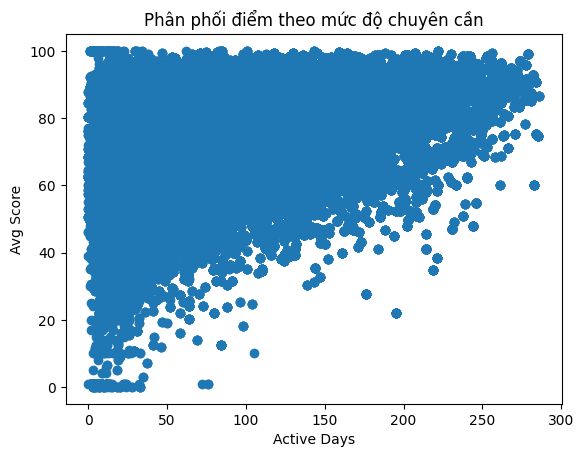

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['active_days'], df['avg_score'])
plt.xlabel('Active Days')
plt.ylabel('Avg Score')
plt.title('Phân phối điểm theo mức độ chuyên cần')
plt.show()

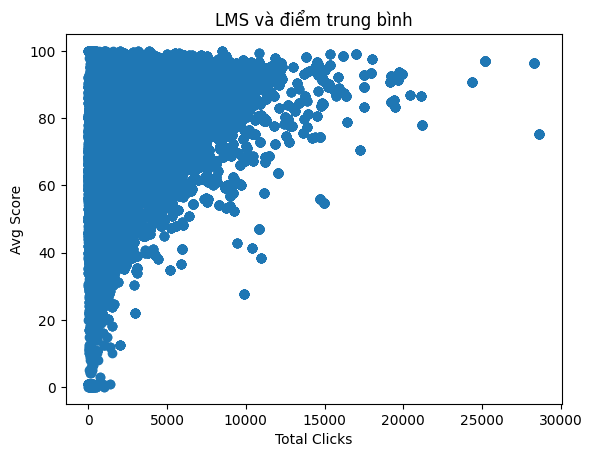

In [ ]:
plt.scatter(df['total_clicks'], df['avg_score'])
plt.xlabel('Total Clicks')
plt.ylabel('Avg Score')
plt.title('LMS và điểm trung bình')
plt.show()

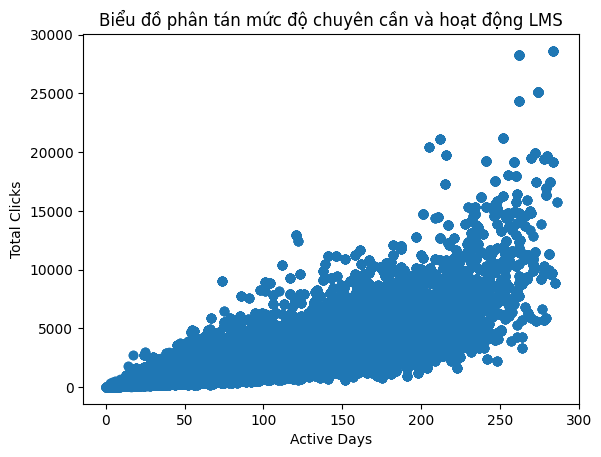

In [ ]:
plt.scatter(df['active_days'], df['total_clicks'])
plt.xlabel('Active Days')
plt.ylabel('Total Clicks')
plt.title('Biểu đồ phân tán mức độ chuyên cần và hoạt động LMS')
plt.show()

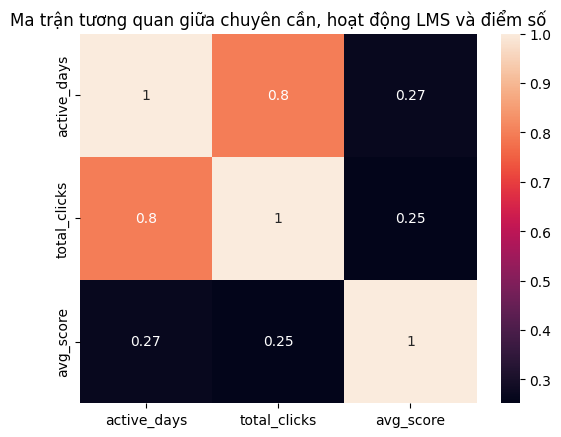

In [ ]:
import seaborn as sns

corr = df[['active_days', 'total_clicks', 'avg_score']].corr()

sns.heatmap(corr, annot=True)
plt.title('Ma trận tương quan giữa chuyên cần, hoạt động LMS và điểm số')
plt.show()

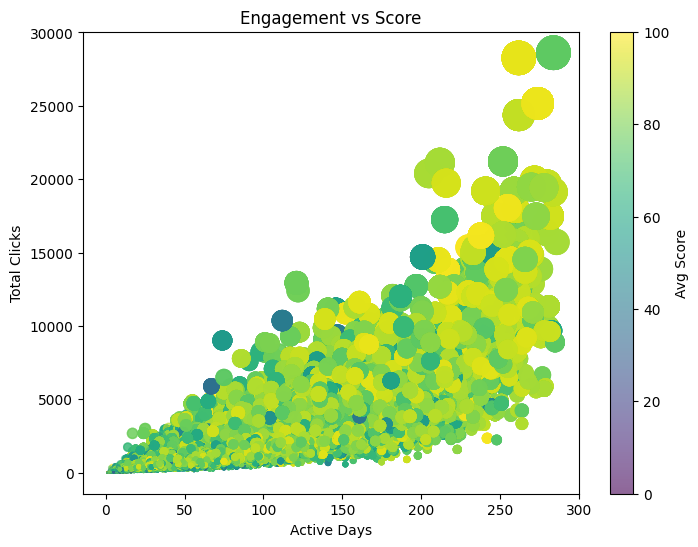

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['active_days'],
    df['total_clicks'],
    c=df['avg_score'],
    s=df['total_clicks']/50,   # size theo clicks
    alpha=0.6
)

plt.xlabel('Active Days')
plt.ylabel('Total Clicks')
plt.title('Engagement vs Score')
plt.colorbar(label='Avg Score')
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['clicks_norm', 'days_norm']] = scaler.fit_transform(
    df[['total_clicks', 'active_days']]
)

df['engagement'] = df['clicks_norm'] + df['days_norm']

In [ ]:
corr = df[['engagement', 'avg_score']].corr()
print(corr)

            engagement  avg_score
engagement    1.000000   0.275045
avg_score     0.275045   1.000000


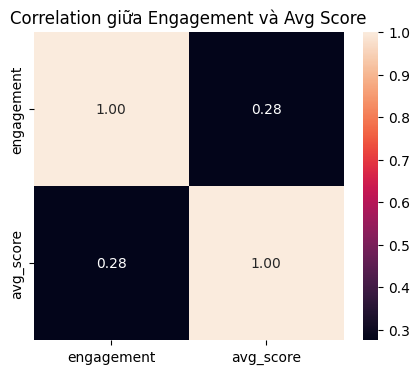

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title('Correlation giữa Engagement và Avg Score')
plt.show()

In [ ]:
import pandas as pd

df['engagement_level'] = pd.cut(
    df['engagement'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

In [ ]:
result_percent = pd.crosstab(
    df['engagement_level'],
    df['final_result'],
    normalize='index'
) * 100

print(result_percent)

final_result      Distinction       Fail       Pass  Withdrawn
engagement_level                                              
Low                 11.512666  18.250398  56.521688  13.715249
Medium              27.362157   5.905058  59.240893   7.491892
High                48.363874   1.570681  45.418848   4.646597


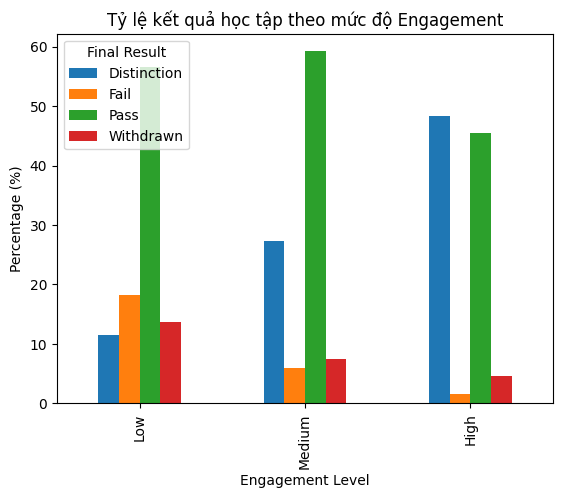

In [ ]:
import matplotlib.pyplot as plt

result_percent.plot(kind='bar')

plt.xlabel('Engagement Level')
plt.ylabel('Percentage (%)')
plt.title('Tỷ lệ kết quả học tập theo mức độ Engagement')

plt.legend(title='Final Result')
plt.show()

In [ ]:
active_days = student_vle.groupby('id_student')['date'].nunique().reset_index()
active_days.columns = ['id_student', 'active_days']

In [ ]:
total_clicks = student_vle.groupby('id_student')['sum_click'].sum().reset_index()
total_clicks.columns = ['id_student', 'total_clicks']

In [ ]:
avg_score = student_assessment.groupby('id_student')['score'].mean().reset_index()
avg_score.columns = ['id_student', 'avg_score']

In [ ]:
df = student_info[['id_student', 'final_result']]

df = df.merge(active_days, on='id_student', how='left')
df = df.merge(total_clicks, on='id_student', how='left')
df = df.merge(avg_score, on='id_student', how='left')

In [ ]:
print("\nDataset sau xử lý:")
print(df.head())


Dataset sau xử lý:
   id_student final_result  active_days  total_clicks  avg_score
0       11391         Pass         40.0         934.0       82.0
1       28400         Pass         80.0        1435.0       66.4
2       30268    Withdrawn         12.0         281.0        NaN
3       31604         Pass        123.0        2158.0       76.0
4       32885         Pass         70.0        1034.0       54.4


In [ ]:
print("\nSố giá trị thiếu còn lại:")
print(df.isnull().sum())


Số giá trị thiếu còn lại:
id_student         0
final_result       0
active_days     2852
total_clicks    2852
avg_score       5866
dtype: int64


In [ ]:
df.fillna(0, inplace=True)

In [ ]:
def classify_activity(x):
    if x < 50:
        return 'Low'
    elif x < 150:
        return 'Medium'
    else:
        return 'High'

df['activity_level'] = df['active_days'].apply(classify_activity)

In [ ]:
df[['active_days', 'total_clicks', 'avg_score']].corr()

,active_days,total_clicks,avg_score
active_days,1.000000,0.831373,0.552719
total_clicks,0.831373,1.000000,0.412395
avg_score,0.552719,0.412395,1.000000


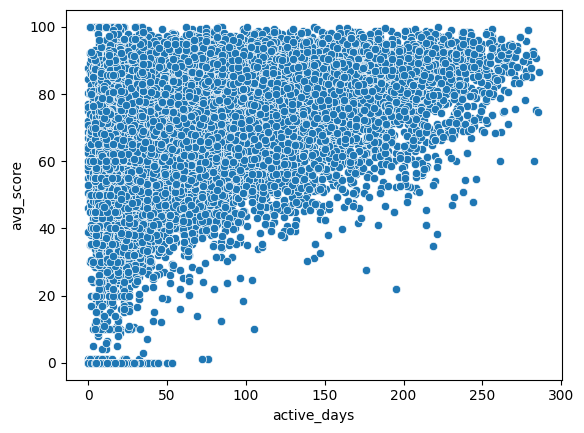

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='active_days', y='avg_score')
plt.show()

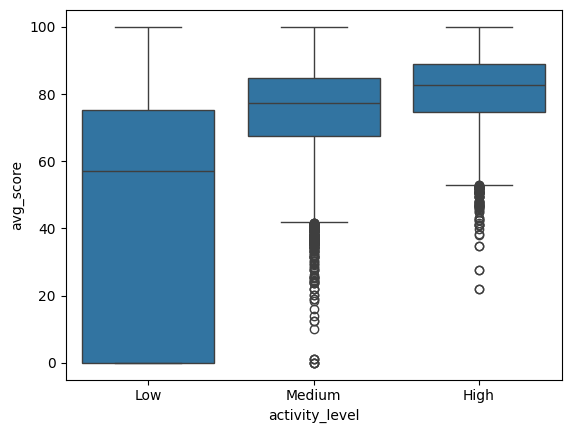

In [ ]:
sns.boxplot(data=df, x='activity_level', y='avg_score')
plt.show()

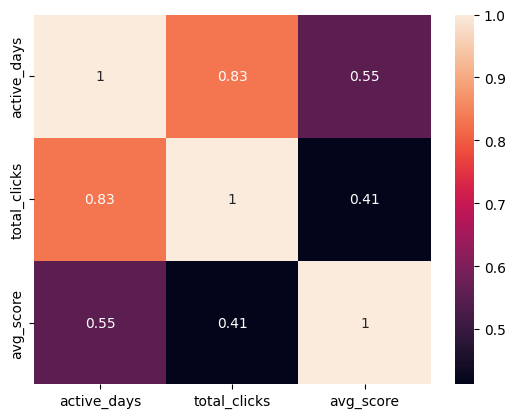

In [ ]:
sns.heatmap(df[['active_days','total_clicks','avg_score']].corr(), annot=True)
plt.show()

In [ ]:
low = df[df['activity_level'] == 'Low']
medium = df[df['activity_level'] == 'Medium']
high = df[df['activity_level'] == 'High']

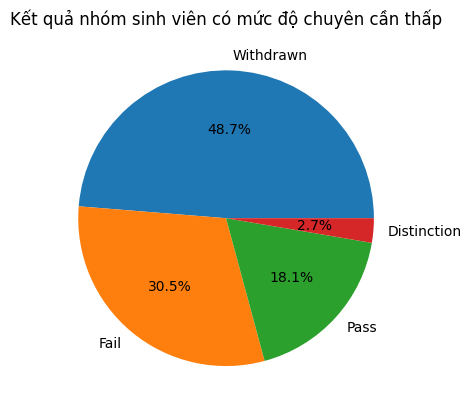

In [ ]:
low['final_result'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Kết quả nhóm sinh viên có mức độ chuyên cần thấp")
plt.ylabel('')
plt.show()

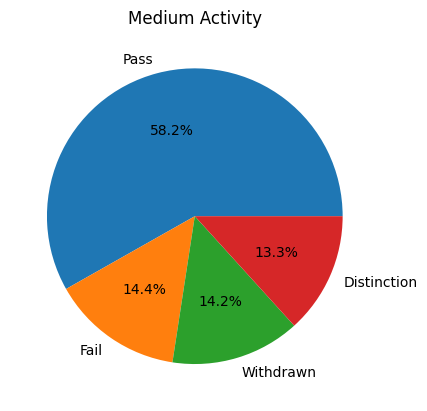

In [ ]:
medium['final_result'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Kết quả nhóm sinh viên có mức độ chuyên cần trung bình")
plt.ylabel('')
plt.show()

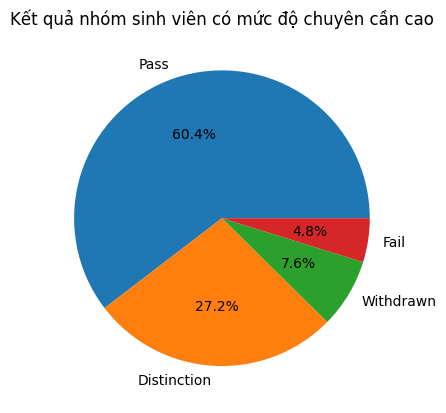

In [ ]:
high['final_result'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Kết quả nhóm sinh viên có mức độ chuyên cần cao")
plt.ylabel('')
plt.show()

In [ ]:
df['engagement_score'] = df['active_days'] + df['total_clicks'] / 100

In [ ]:
def classify_engagement(x):
    if x < 100:
        return 'Low'
    elif x < 300:
        return 'Medium'
    else:
        return 'High'

df['engagement_level'] = df['engagement_score'].apply(classify_engagement)

<Axes: xlabel='engagement_score', ylabel='avg_score'>

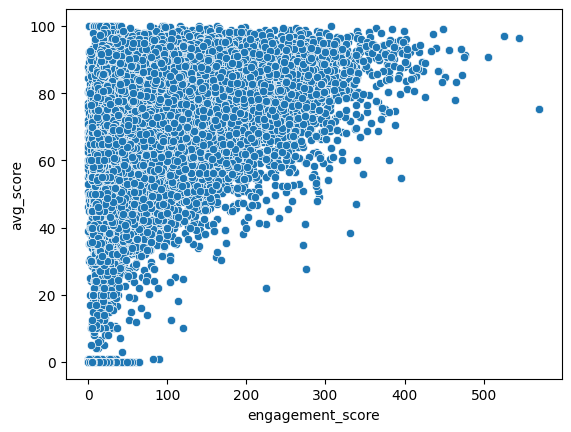

In [ ]:
sns.scatterplot(data=df, x='engagement_score', y='avg_score')

<Axes: xlabel='engagement_level', ylabel='avg_score'>

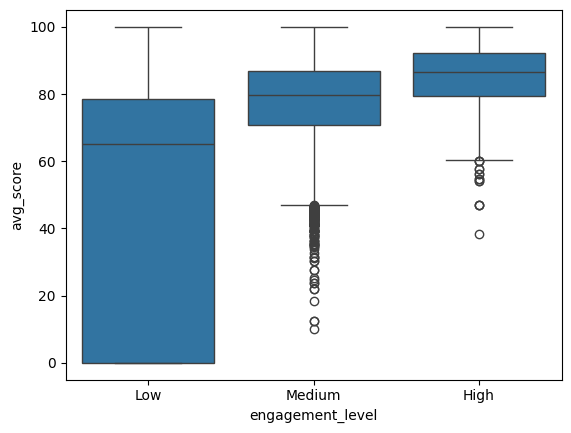

In [ ]:
sns.boxplot(data=df, x='engagement_level', y='avg_score')

<Axes: ylabel='count'>

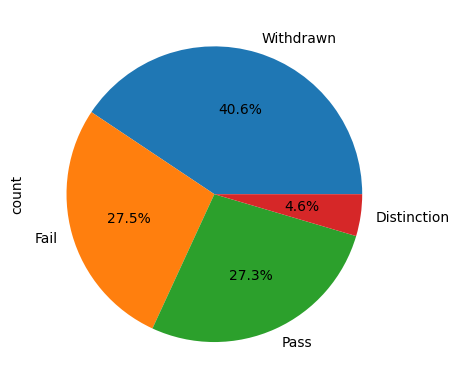

In [ ]:
df[df['engagement_level']=='Low']['final_result'].value_counts().plot.pie(autopct='%1.1f%%')

<Axes: ylabel='count'>

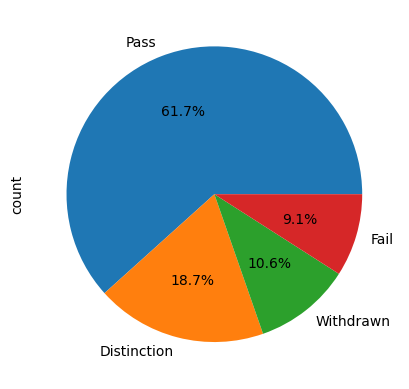

In [ ]:
df[df['engagement_level']=='Medium']['final_result'].value_counts().plot.pie(autopct='%1.1f%%')

<Axes: ylabel='count'>

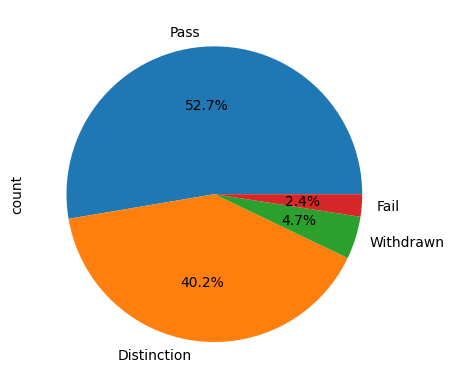

In [ ]:
df[df['engagement_level']=='High']['final_result'].value_counts().plot.pie(autopct='%1.1f%%')